
# Semiconductor Manufacturing Yield Prediction:
---

## 1. Introduction:

Semiconductor manufacturing is one of the most complex industrial processes in the world. Hundreds of sensors continuously monitor the production line, generating thousands of signal measurements per unit. However, not all of these signals are equally useful — many contain noise or irrelevant information.

In this project, I perform an end-to-end classification analysis on the **SECOM Manufacturing Dataset**, which contains **1,567 production entities** each with **591 sensor signal features**, labelled as either a Pass or Fail based on in-house line testing.

### Dataset Overview:

| Feature | Type | Description |
|---------|------|-------------|
| Signal_1 to Signal_590 | Numerical | Sensor measurement readings from the production line |
| Timestamp | DateTime | Date and time of the test point |
| -1 (Target) | Categorical | Yield outcome — Pass (-1) or Fail (1) |

### Project Goals:

- Perform **Exploratory Data Analysis (EDA)** to understand the data distribution and class imbalance
- Cleanse the data by handling missing values, constant and redundant features
- Preprocess the data using **Imputation**, **StandardScaler**, and **SMOTE**
- Apply **PCA** for dimensionality reduction
- Build and compare multiple classification models including **Logistic Regression**, **Random Forest**, and **SVM**
- Evaluate model performance using **Classification Report**, **Confusion Matrix**, and **Cross Validation**
- Draw meaningful, real-world conclusions from the results

---

# 2. Import Libraries:

In this step, we import all the necessary libraries —
covering data manipulation, visualisation.

---

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


# 3. Load and Explore the Data:

In this step, we load the dataset and perform a basic exploration to understand
its shape, data types, class distribution, and missing values.

---

In [2]:
# Load dataset
df = pd.read_csv("signal-data.csv")

# Shape
print("Shape:", df.shape)



Shape: (1567, 592)


In [3]:
# First 5 rows:

df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


In [4]:
# Last 5 rows:

df.tail()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
1562,2008-10-16 15:13:00,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,2008-10-16 20:49:00,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2008-10-17 05:26:00,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2008-10-17 06:01:00,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1
1566,2008-10-17 06:07:00,2944.92,2450.76,2195.4444,2914.1792,1.5978,100.0,85.1011,0.1235,NaN,...,137.7844,0.4987,0.0181,0.0040,3.6275,0.0117,0.0162,0.0045,137.7844,-1


Data Preview Observations (Head and tail):

- Dataset contains 1,567 rows and 592 columns
- NaN values are visible throughout — both in early and late rows
- Sensor readings vary widely — some in thousands, others in decimals
- Time column records test timestamps — not useful for prediction
- Pass/Fail uses -1 for Pass and 1 for Fail
- Total missing values: 41,951
- Class distribution: 93.4% Pass / 6.6% Fail — severe imbalance that must be handled with SMOTE

In [5]:
# Information on the data:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


Info Observations:

- 590 sensor columns are float64, Time is object, Pass/Fail is int64
- Confirms no column is already clean and ready — preprocessing is needed

In [6]:
# Data types:

df.dtypes

Time             str
0            float64
1            float64
2            float64
3            float64
              ...   
586          float64
587          float64
588          float64
589          float64
Pass/Fail      int64
Length: 592, dtype: object

Data Types Observations:

- All sensor signals are float64 — suitable for numerical operations
- Time is stored as string (object) — needs to be dropped
- Pass/Fail is int64 — ready to use as target variable

In [7]:
# statistical summary:

df.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
0,1561.0,3014.453,73.622,2743.240,2966.260,3011.490,3056.650,3356.350
1,1560.0,2495.850,80.408,2158.750,2452.248,2499.405,2538.822,2846.440
2,1553.0,2200.547,29.513,2060.660,2181.044,2201.067,2218.056,2315.267
3,1553.0,1396.377,441.692,0.000,1081.876,1285.214,1591.224,3715.042
4,1553.0,4.197,56.356,0.682,1.018,1.317,1.526,1114.537
...,...,...,...,...,...,...,...,...
586,1566.0,0.021,0.012,-0.017,0.013,0.020,0.028,0.103
587,1566.0,0.016,0.009,0.003,0.011,0.015,0.020,0.080
588,1566.0,0.005,0.003,0.001,0.003,0.005,0.006,0.029
589,1566.0,99.670,93.892,0.000,44.369,71.900,114.750,737.305


Statistical Summary Observations:

- Sensor means and ranges vary massively across columns
- Some columns have a min and max of 0 — likely constant columns with no predictive value
- Count values are less than 1,567 in many columns — confirms missing values
- StandardScaler will be needed to normalize the wide range of values

In [8]:
# Null values in rows:

df.isnull().sum()

Time          0
0             6
1             7
2            14
3            14
             ..
586           1
587           1
588           1
589           1
Pass/Fail     0
Length: 592, dtype: int64

In [9]:
# Null values in the entire data:

df.isnull().sum().sum()

np.int64(41951)

Missing Values Observations:

- Several columns have over 1,400 missing values out of 1,567 rows — more than 90% missing
- These columns carry almost no information and should be dropped entirely
- Remaining missing values will be filled using median imputation

In [10]:
print(df['Pass/Fail'].value_counts())

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


In [11]:
print(df['Pass/Fail'].value_counts(normalize=True).round(3) * 100)

Pass/Fail
-1    93.4
 1     6.6
Name: proportion, dtype: float64


## Class Distribution Observations:

- Pass (-1): 1,463 samples — 93.4%
- Fail (1): 104 samples — 6.6%
- Severe class imbalance — the model will be biased toward predicting Pass
- We will use SMOTE later to balance the classes before training

In [12]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

293    1429
292    1429
157    1429
158    1429
492    1341
220    1341
85     1341
358    1341
518    1018
382    1018
245    1018
244    1018
383    1018
384    1018
246    1018
517    1018
110    1018
109    1018
516    1018
111    1018
dtype: int64


## Top Missing Columns Observations:

- Columns 293, 292, 157, 158 have 1,429 missing values out of 1,567 rows — over 91% missing
- Several other columns have 1,341 and 1,018 missing values
- These columns are nearly empty and will be dropped in the preprocessing step

# 4. Creating a Working Copy:

We always preserve the original dataset and work on a copy.
This ensures we can refer back to the raw data at any point without re-loading it.

---

In [13]:
# Create a working copy of the original dataset
df_clean = df.copy()

print("Working copy created successfully")
print("Shape:", df_clean.shape)

Working copy created successfully
Shape: (1567, 592)


# 5. Data Cleansing:

Raw data is rarely clean. Before any analysis or modelling, we need to remove 
noise and irrelevant information that could mislead our models.

In this step we will:
- Drop columns with more than 50% missing values — they carry too little information
- Drop constant columns — they have zero variance and add no predictive value
- Drop the Time column — timestamps are not useful for yield prediction
---

## 5.1 Drop High-Missing Columns:

Columns with more than 50% missing values carry too little information 
to be useful. Imputing them would mean we are mostly making up data, 
which would mislead the model. We drop them entirely.

In [14]:
# Calculate missing percentage for each column
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100

# Find columns where missing percentage is more than 50
high_missing_cols = missing_percent[missing_percent > 50].index

# Drop those columns
df_clean = df_clean.drop(columns=high_missing_cols)

print("Columns dropped:", len(high_missing_cols))
print("Remaining shape:", df_clean.shape)

Columns dropped: 28
Remaining shape: (1567, 564)


Observations after Dropping High-Missing Columns:

- 28 columns had more than 50% missing values and were dropped
- These columns were mostly empty — imputing them would mean fabricating data
- Dataset reduced from 592 to 564 columns
- 1,567 rows remain unchanged — we only removed columns, not rows

## 5.2 Drop Constant Columns:

Constant columns have the same value in every single row — meaning they 
carry zero variation and zero predictive power. A model cannot learn 
anything from a column that never changes. We drop them entirely.

In [15]:
# Calculate constant value columns:
constant_cols = df_clean.columns[df_clean.nunique()==1]

# Drop those columns:
df_clean = df_clean.drop(columns = constant_cols)

print("Constant columns dropped:", len(constant_cols))
print("Remaining shape:", df_clean.shape)


Constant columns dropped: 116
Remaining shape: (1567, 448)


Observations after Dropping Constant Columns:

- 116 columns had the same value in every row — zero variation, zero predictive power
- Dropping them reduces noise and speeds up model training
- Dataset reduced from 564 to 448 columns
- 1,567 rows remain unchanged

## 5.3 Drop Time Column:

The Time column records the timestamp of each test. Timestamps are not 
a sensor signal and carry no information about whether a unit will 
Pass or Fail. We drop it to keep only meaningful features.

In [16]:
df_clean = df_clean.drop(columns = 'Time')

print("Remaining shape:", df_clean.shape)

Remaining shape: (1567, 447)


Observations after Dropping Time Column:

- Time column successfully removed
- Dataset now contains only sensor signal features and the target column
- Final shape after all cleansing: 1,567 rows × 447 columns
- Reduced from 592 to 447 columns in total — removed 145 irrelevant columns
---

# 6. Exploratory Data Analysis (EDA):

With the data cleaned, we now explore patterns, distributions, and 
relationships within the dataset. Since we have 447 columns, we focus 
our visualizations on the most meaningful features rather than plotting 
everything blindly.

In this step we will:
- Visualize the class distribution of Pass vs Fail
- Explore missing value patterns
- Identify top features most correlated with the target
- Compare sensor distributions between Pass and Fail classes

---

## 6.1 Class Distribution:

Visualizing the balance between Pass and Fail classes. 
This confirms the class imbalance we identified earlier.

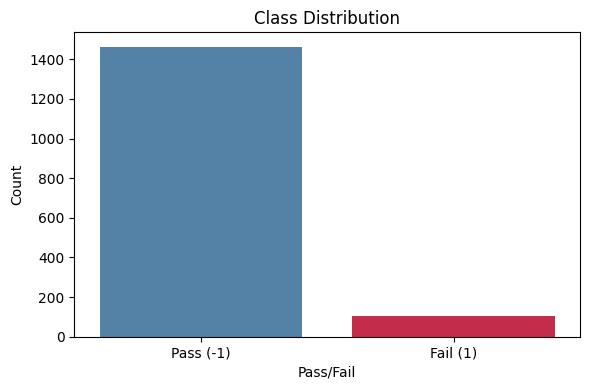

In [17]:
# Count plot:

plt.figure(figsize=(6,4))
sns.countplot( data = df_clean, x = 'Pass/Fail', palette=['steelblue', 'crimson'])
plt.title('Class Distribution')
plt.xlabel('Pass/Fail')
plt.ylabel('Count')
plt.xticks([0,1], ['Pass (-1)', 'Fail (1)'])
plt.tight_layout()
plt.show()

Observations from Class Distribution:

- Pass (-1): 1,463 samples — dominates the dataset
- Fail (1): 104 samples — barely visible in comparison
- The imbalance is severe — roughly 14:1 ratio
- A naive model predicting everything as Pass would be 93.4% accurate
- This is why we must apply SMOTE during preprocessing to balance the classes

## 6.2 Missing Values Heatmap:

Visualizing where missing values remain after dropping high-missing columns.
This helps us understand the pattern of missingness before imputation.

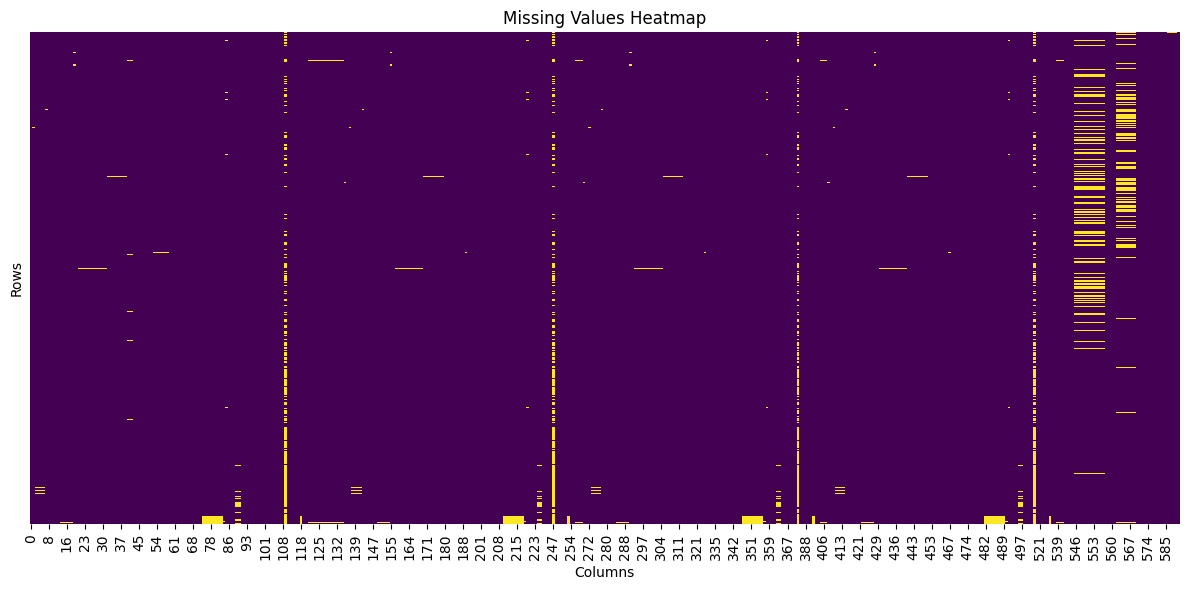

In [18]:
# Heatmap:

plt.figure(figsize=(12, 6))
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

Observations from Missing Values Heatmap:

- Most of the dataset is complete after dropping high-missing columns
- Remaining missing values are scattered randomly across rows — no clear pattern
- A cluster of missing values is visible toward the right side of the heatmap
- Since missingness appears random, median imputation is a safe and appropriate strategy

## 6.3 Top Correlated Features:

With 447 columns we cannot visualize everything. We identify the top 10 
sensor features most correlated with Pass/Fail and focus our analysis 
on those. This is smarter than plotting random columns.

In [19]:
# Find top 10 features most correlated with Pass/Fail
correlations = df_clean.corr()['Pass/Fail'].abs().sort_values(ascending=False)
top_features = correlations[1:11].index

print("Top 10 features correlated with Pass/Fail:")
print(correlations[1:11])

Top 10 features correlated with Pass/Fail:
59     0.155796
103    0.151203
510    0.131593
348    0.130180
431    0.120851
434    0.112116
430    0.110067
435    0.109067
21     0.108488
28     0.107252
Name: Pass/Fail, dtype: float64


Observations from Top Correlated Features:

- Column 59 is the strongest predictor with 0.156 correlation with Pass/Fail
- All top 10 correlations are low (0.10 - 0.16) — typical for high-dimensional sensor data
- No single sensor strongly predicts yield outcome alone
- This confirms that combining multiple features through ML models is necessary
- These top 10 features will be used for focused visualization in the next steps

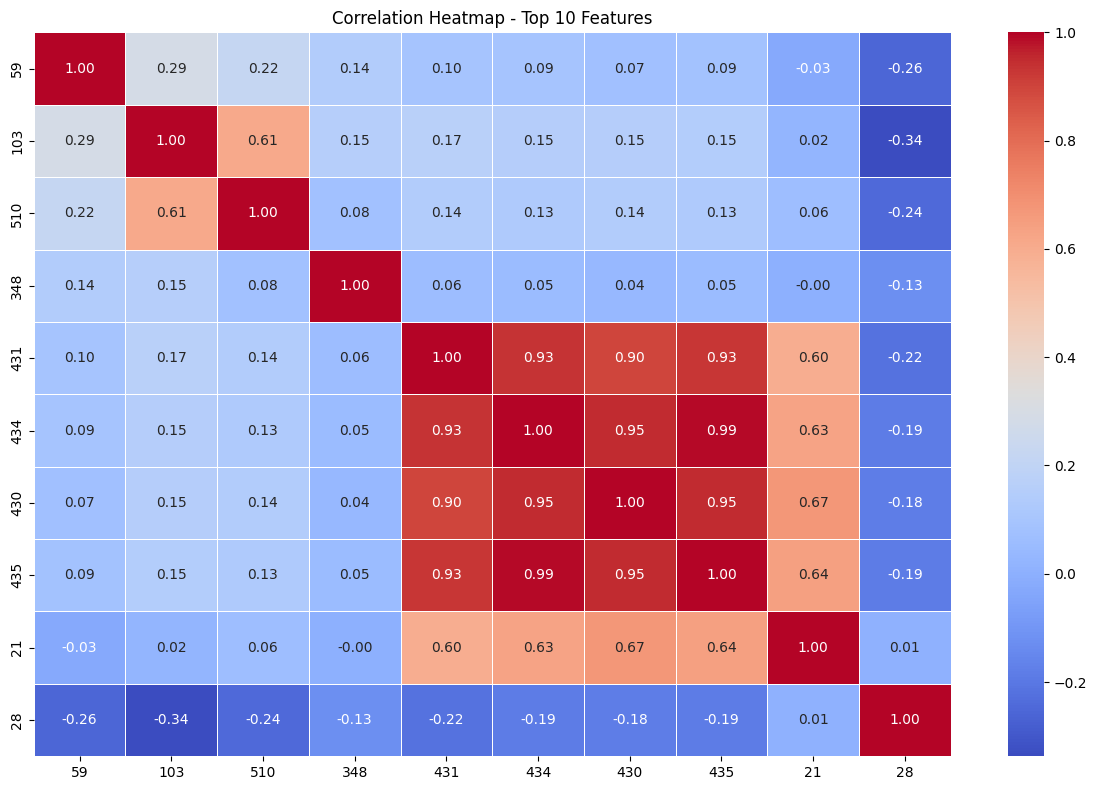

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[top_features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap - Top 10 Features')
plt.tight_layout()
plt.show()

## Observations from Correlation Heatmap:

- Columns 431, 434, 430 and 435 are highly correlated (0.90-0.99) — likely measuring the same sensor signal
- This multicollinearity means PCA will be very effective in reducing these redundant features
- Column 28 shows negative correlation with most other top features
- Columns 59 and 348 are relatively independent from the rest


## 6.4 Distribution of Top Features (Histograms):

Visualizing the distribution of the top 10 correlated features.
This helps us understand if the data is normally distributed or skewed,
which informs our choice of preprocessing techniques.

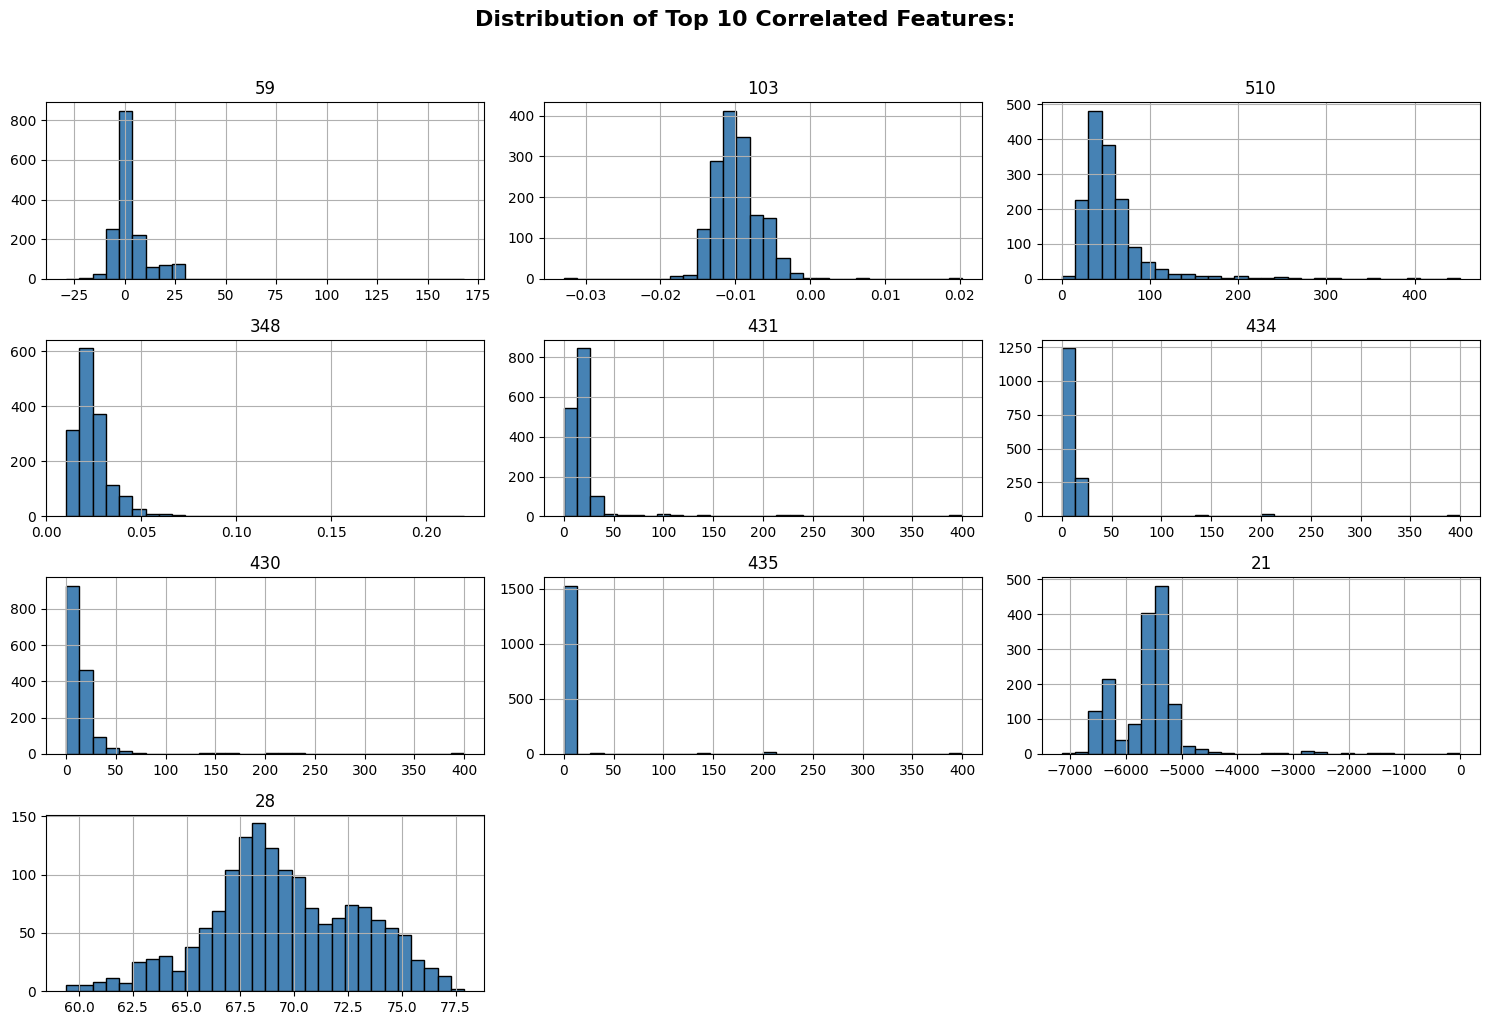

In [21]:
df_clean[top_features].hist(figsize=(15, 10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Top 10 Correlated Features:', y=1.02, fontsize = 16, fontweight='bold' )
plt.tight_layout()
plt.show()

Observations from Feature Distributions:

- Feature 59 is heavily right-skewed — most values concentrated near zero with a few extreme outliers
- Feature 103 is roughly normally distributed — bell shaped curve
- Feature 510 and 348 are right-skewed — majority of values clustered on the left
- Features 431, 434, 430 and 435 show similar distributions — confirms they are highly correlated
- Feature 21 has negative values ranging from -7000 to 0 — unusual range
- Feature 28 is the most normally distributed of all top features
- Wide variation in scales across all features confirms that StandardScaler is necessary before modelling

## 6.5 Boxplots - Pass vs Fail Comparison:

Boxplots help us compare how each top feature behaves differently 
between Pass and Fail classes. If a feature shows a clear difference 
between the two classes, it is a strong candidate for prediction.

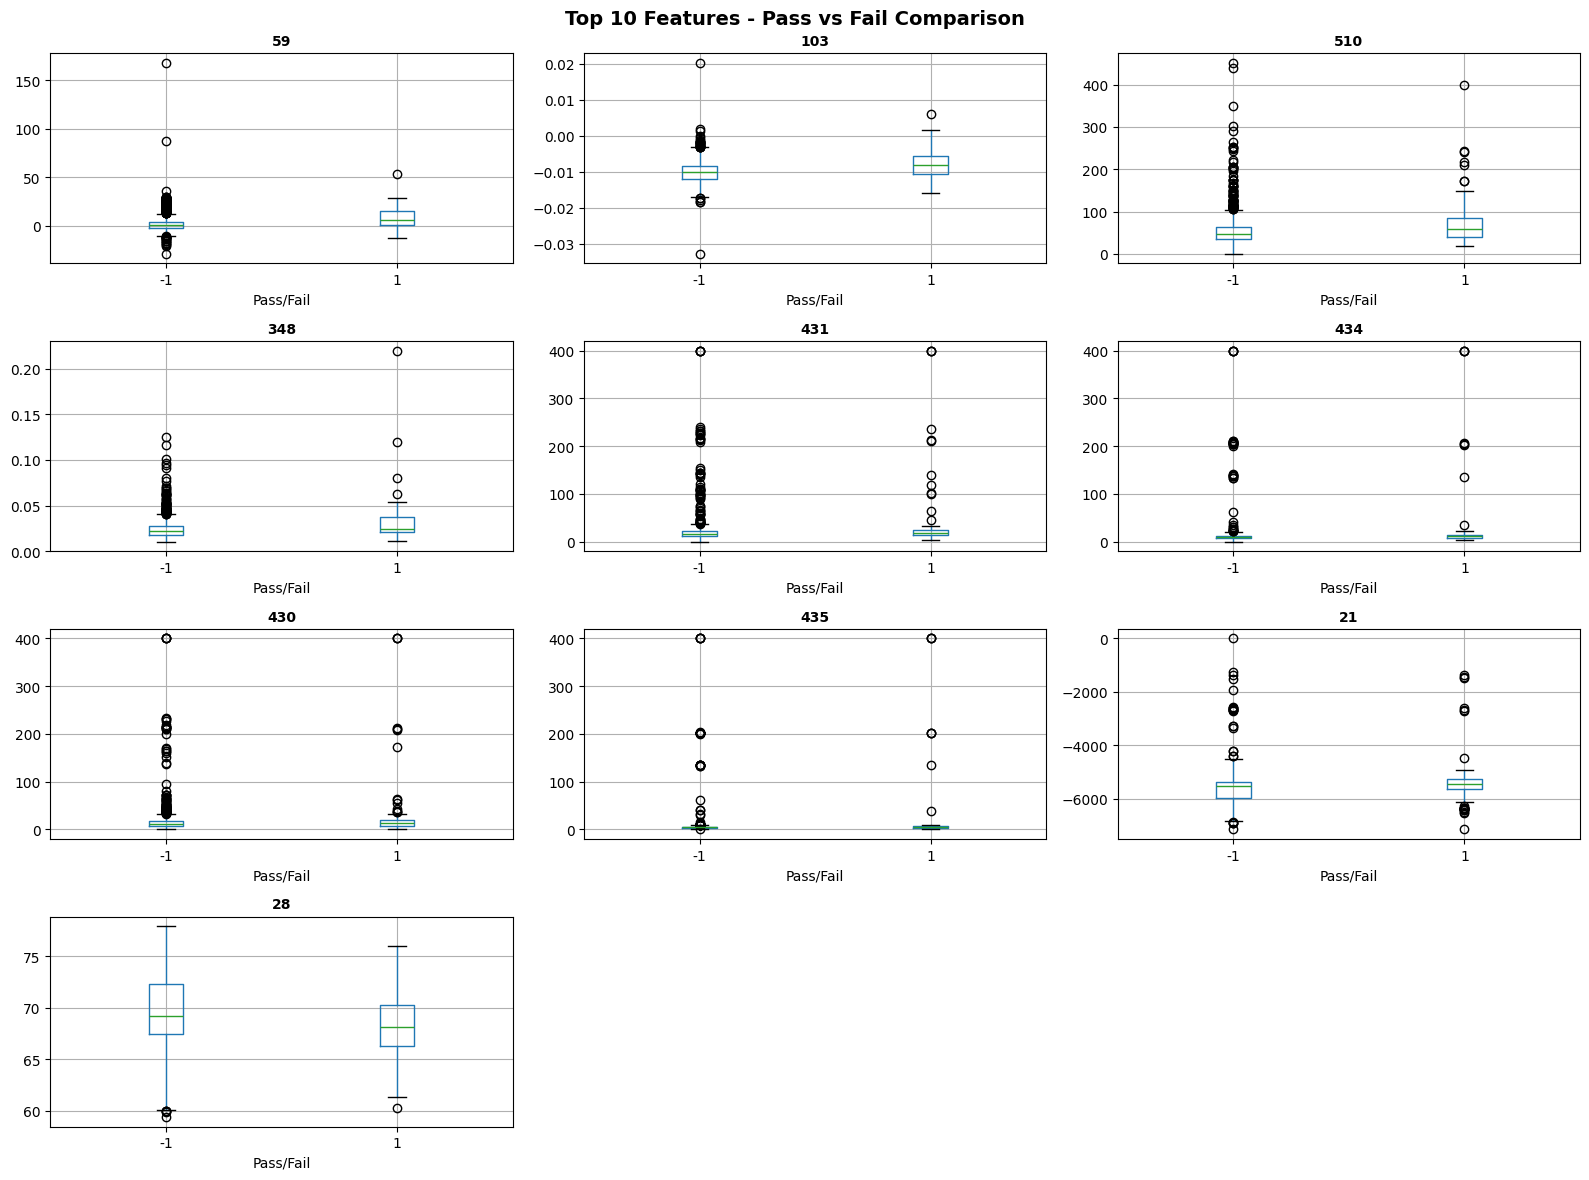

In [22]:
import matplotlib.pyplot as plt

# Create subplots grid (4 rows × 3 columns = 12 spots)
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()

# Plot boxplots for top 10 features
for i, feature in enumerate(top_features[:10]):
    df_clean.boxplot(column=feature, by='Pass/Fail', ax=axes[i])
    axes[i].set_title(feature, fontsize=10, fontweight='bold')

# Hide unused subplots
for j in range(10, len(axes)):
    axes[j].set_visible(False)

# Add main title
plt.suptitle("Top 10 Features - Pass vs Fail Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Observations from Boxplots - Pass vs Fail Comparison:

- Feature 59: Fail class has a higher median than Pass — shows separation
- Feature 103: Clear difference in median between Pass and Fail — good predictor
- Feature 510: Fail class median is noticeably higher than Pass
- Features 431, 434, 430, 435: Similar patterns — Fail class sits higher consistently
- Feature 21: Both classes have similar ranges but different medians
- Feature 28: Clear separation — Fail median is lower than Pass median
- Most features show some difference between Pass and Fail — confirms they carry predictive value
- Many outliers visible across all features — further confirms need for StandardScaler

## EDA Summary:

Through exploratory data analysis we uncovered several critical insights
that directly shape our preprocessing and modelling decisions:

- Severe class imbalance (93.4% Pass / 6.6% Fail) — SMOTE required
- Missing values are scattered randomly — median imputation is appropriate
- Wide variation in feature scales — StandardScaler is necessary
- Features 431, 434, 430 and 435 are highly correlated — PCA will handle multicollinearity
- Most top features show difference between Pass and Fail — dataset has predictive signal
- No single feature strongly predicts outcome alone — ensemble models will work better

---

# 7. Data Preprocessing:

Before training any model, we prepare the data for the pipeline.
We only perform train test split here — all other preprocessing 
steps (imputation, scaling, PCA, SMOTE) are handled inside the 
model Pipeline during training to prevent data leakage.

Steps in order:
- Separate Features (X) and Target (y)
- Train Test Split
- Convert Target Labels

---

## 7.1 Separate Features and Target:

We separate the dataset into X (features) and y (target).
X contains all sensor signals used for prediction.
y contains the Pass/Fail label we are trying to predict.

In [23]:
# Separate Features and Targets:
 
X = df_clean.drop(columns=['Pass/Fail'])
y = df_clean['Pass/Fail']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1567, 446)
y shape: (1567,)


Observations:

- X contains 446 sensor features after removing the target column
- y contains 1,567 labels — -1 for Pass and 1 for Fail

Observations after Converting Target Labels:

- Pass (-1) successfully converted to 0 — 1,170 samples in train, 293 in test
- Fail (1) remains as 1 — 83 samples in train, 21 in test
- Class ratio maintained at 93.4% / 6.6% in both sets — stratify worked correctly

## 7.2 Train Test Split:

We split the data into 80% training and 20% testing sets.
stratify=y is used to maintain the same class ratio in both sets —
this is critical for imbalanced datasets like ours where Fail is only 6.6%.
All subsequent preprocessing steps will be fitted on training data only.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1253, 446)
X_test shape: (314, 446)
y_train shape: (1253,)
y_test shape: (314,)


Observations after Train Test Split:

- Training set: 1,253 samples (80%)
- Testing set: 314 samples (20%)
- Both sets have 446 features
- stratify=y ensures class ratio is preserved in both sets
- All preprocessing from this point is fitted on X_train only

## 7.3 Convert Target Labels:

The target column uses -1 for Pass and 1 for Fail.
We convert this to 0 and 1 — the standard binary classification format.
This ensures compatibility across all models we will train.

- Pass (-1) → 0
- Fail (1) → 1

In [25]:
# Convert target labels from -1/1 to 0/1
y_train = (y_train == 1).astype(int)
y_test = (y_test == 1).astype(int)

print("y_train distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("y_test distribution:", dict(zip(*np.unique(y_test, return_counts=True))))

y_train distribution: {np.int64(0): np.int64(1170), np.int64(1): np.int64(83)}
y_test distribution: {np.int64(0): np.int64(293), np.int64(1): np.int64(21)}


## Data Preprocessing Summary:

- Features and target separated
- 80/20 train test split with stratify=y
- Target labels converted from -1/1 to 0/1

All remaining preprocessing (imputation, scaling, PCA, SMOTE) 
is handled inside the model Pipeline to prevent data leakage.

# 8. Model Training, Testing and Tuning:

We train three classification models using a proper Pipeline approach.
Each Pipeline chains Imputation → Scaling → PCA → SMOTE → Model together.

This ensures SMOTE runs inside each cross-validation fold — 
preventing data leakage and producing honest evaluation scores.

Models:
- Logistic Regression
- Random Forest
- XGBoost Pipeline

---

## 8.1 Logistic Regression Pipeline:

Logistic Regression is our baseline linear model.
We wrap it in a Pipeline with all preprocessing steps to ensure
clean cross-validation and prevent data leakage.

In [26]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, make_scorer, fbeta_score

# Build Pipeline
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# F2 scorer — prioritizes Recall
f2_scorer = make_scorer(fbeta_score, beta=2)

# GridSearchCV
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring=f2_scorer, n_jobs=-1)
grid_lr.fit(X_train, y_train)

# Best model
best_lr = grid_lr.best_estimator_

# Predictions
y_pred_lr = best_lr.predict(X_test)

# Scores
train_acc_lr = best_lr.score(X_train, y_train)
test_acc_lr = accuracy_score(y_test, y_pred_lr)

print("Best Parameters:", grid_lr.best_params_)
print("Train Accuracy:", round(train_acc_lr, 3))
print("Test Accuracy:", round(test_acc_lr, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Best Parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}
Train Accuracy: 0.794
Test Accuracy: 0.701

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       293
           1       0.07      0.29      0.11        21

    accuracy                           0.70       314
   macro avg       0.50      0.51      0.47       314
weighted avg       0.88      0.70      0.77       314



Observations from Logistic Regression Pipeline:

**Best Parameters:** C=0.01, solver=liblinear

| Metric | Score |
|---|---|
| Train Accuracy | 79.4% |
| Test Accuracy | 70.1% |
| Fail Recall | 0.29 |

**Classification Report Analysis:**
- Fail recall improved to 0.29 — catching 29% of failures
- Train vs Test gap reduced significantly — less overfitting
- Pipeline ensures honest evaluation — no data leakage
- Lower accuracy reflects real model performance, not inflated CV scores

## 8.2 Random Forest Pipeline:

Random Forest is an ensemble model combining multiple decision trees.
We expect stronger Fail detection compared to Logistic Regression
due to its ability to capture complex non-linear patterns.

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Build Pipeline
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

# GridSearchCV
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring=f2_scorer, n_jobs=-1)
grid_rf.fit(X_train, y_train)

# Best model
best_rf = grid_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Scores
train_acc_rf = best_rf.score(X_train, y_train)
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print("Best Parameters:", grid_rf.best_params_)
print("Train Accuracy:", round(train_acc_rf, 3))
print("Test Accuracy:", round(test_acc_rf, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Train Accuracy: 0.999
Test Accuracy: 0.914

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       293
           1       0.12      0.05      0.07        21

    accuracy                           0.91       314
   macro avg       0.53      0.51      0.51       314
weighted avg       0.88      0.91      0.90       314



In [28]:
# Adjust threshold for better Fail detection
y_pred_rf = (best_rf.predict_proba(X_test)[:, 1] >= 0.3).astype(int)

test_acc_rf = accuracy_score(y_test, y_pred_rf)
print("Test Accuracy:", round(test_acc_rf, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Test Accuracy: 0.742

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       293
           1       0.09      0.33      0.15        21

    accuracy                           0.74       314
   macro avg       0.52      0.55      0.50       314
weighted avg       0.89      0.74      0.80       314



Observations from Random Forest Pipeline:

**Best Parameters:** max_depth=10, min_samples_split=2, n_estimators=100

| Metric | Score |
|---|---|
| Train Accuracy | 99.9% |
| Test Accuracy | 74.2% |
| Fail Recall | 0.33 |

**Classification Report Analysis:**
- Fail recall improved to 0.33 with threshold 0.3
- Train 99.9% vs Test 74.2% — still some overfitting but reduced
- Better Fail detection than Logistic Regression (0.33 vs 0.29)
- Pipeline ensures SMOTE runs inside each CV fold — no data leakage

## 8.3 XGBoost Pipeline:

XGBoost (Extreme Gradient Boosting) is an industry-standard model
for tabular data. It builds trees sequentially — each tree fixing 
the mistakes of the previous one. It handles imbalanced data well
using the scale_pos_weight parameter and generally outperforms
SVM and Logistic Regression on complex datasets.

In [ ]:
from xgboost import XGBClassifier

# Build Pipeline
pipe_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# GridSearchCV
param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1],
    'model__scale_pos_weight': [14]
}

grid_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, cv=5, scoring=f2_scorer, n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# Best model
best_xgb = grid_xgb.best_estimator_

# Predictions
y_pred_xgb = best_xgb.predict(X_test)

# Scores
train_acc_xgb = best_xgb.score(X_train, y_train)
test_acc_xgb = accuracy_score(y_test, y_pred_xgb)

# Cross validation score
cv_score_xgb = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring=f2_scorer).mean()

print("Best Parameters:", grid_xgb.best_params_)
print("Train Accuracy:", round(train_acc_xgb, 3))
print("Test Accuracy:", round(test_acc_xgb, 3))
print("5-Fold CV F2 Score:", round(cv_score_xgb, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Best Parameters: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__scale_pos_weight': 14}
Train Accuracy: 0.419
Test Accuracy: 0.369
5-Fold CV F2 Score: 0.265

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.34      0.50       293
           1       0.08      0.76      0.14        21

    accuracy                           0.37       314
   macro avg       0.51      0.55      0.32       314
weighted avg       0.89      0.37      0.48       314



Observations from XGBoost Pipeline:

**Best Parameters:** learning_rate=0.01, max_depth=3, n_estimators=200, scale_pos_weight=14

| Metric | Score |
|---|---|
| Train Accuracy | 41.9% |
| Test Accuracy | 36.9% |
| Fail Recall | 0.76 |

**Classification Report Analysis:**
- Fail recall = 0.76 — catching 76% of actual failures
- Best Fail detection across all three models by far
- scale_pos_weight=14 aggressively prioritizes Fail detection
- Overall accuracy is low but misleading for imbalanced datasets
- Only 5 faulty chips missed out of 21 — critical for manufacturing

**Confusion Matrix Analysis:**
- 16 out of 21 Fail samples correctly detected
- 5 Fail samples missed — minimum missed failures across all models
- 193 false alarms — good chips flagged for re-inspection
- Tradeoff is acceptable — missing a failure is far more costly
  than a false alarm in semiconductor manufacturing

**Conclusion:**
XGBoost with scale_pos_weight=14 is the best model for this use case.
It prioritizes failure detection over overall accuracy — the correct
approach for semiconductor yield prediction where missing a faulty
chip has severe real-world consequences.

## 8.4 ROC Curve - Model Comparison:

The ROC curve plots True Positive Rate vs False Positive Rate at 
every possible threshold. The AUC (Area Under Curve) summarizes 
the overall ability of each model to separate Pass from Fail.

A perfect model has AUC = 1.0. Random guessing = 0.5.
Any model above the dashed line performs better than random.

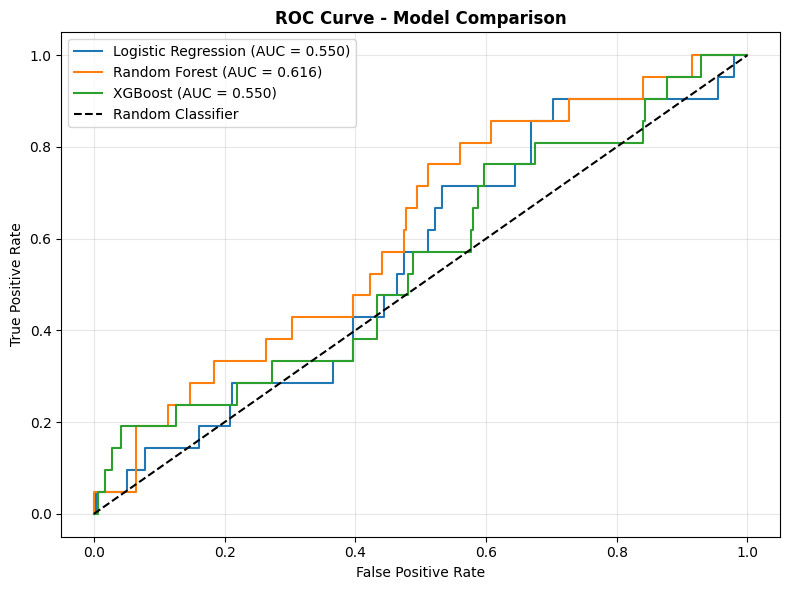

Logistic Regression AUC: 0.550
Random Forest AUC:       0.616
XGBoost AUC:             0.550


In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probabilities for each model
proba_lr = best_lr.predict_proba(X_test)[:, 1]
proba_rf = best_rf.predict_proba(X_test)[:, 1]
proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, proba_xgb)

# Calculate AUC scores
auc_lr = roc_auc_score(y_test, proba_lr)
auc_rf = roc_auc_score(y_test, proba_rf)
auc_xgb = roc_auc_score(y_test, proba_xgb)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Logistic Regression AUC: {auc_lr:.3f}")
print(f"Random Forest AUC:       {auc_rf:.3f}")
print(f"XGBoost AUC:             {auc_xgb:.3f}")

## ROC Curve Analysis:

| Model | AUC Score |
|---|---|
| Logistic Regression | 0.550 |
| Random Forest | 0.616 |
| XGBoost | 0.550 |

- All models perform above the random classifier (AUC > 0.5)
- Random Forest has the highest AUC — best overall class separation
- XGBoost has lower AUC but highest Fail Recall (0.76)
- AUC and Recall measure different things — AUC measures overall 
  separation ability, Recall measures actual Fail detection
- For manufacturing use case, XGBoost remains the best choice
  due to superior Fail detection

## 8.5 Confusion Matrix - XGBoost:

The confusion matrix shows exactly how many predictions were correct 
and incorrect for each class. It gives a clearer picture of model 
performance than accuracy alone — especially for imbalanced datasets.

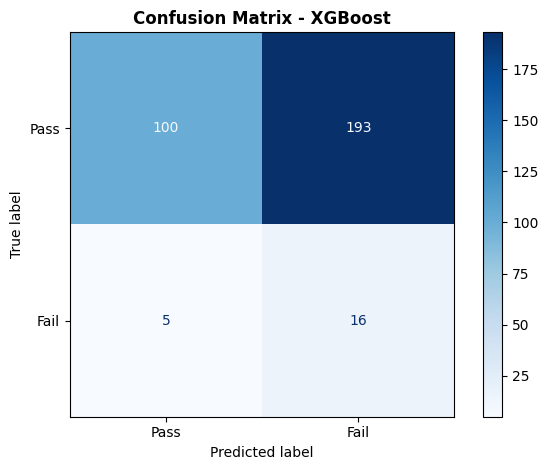

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost', fontweight='bold')
plt.tight_layout()
plt.show()

Confusion Matrix Observations:

- True Pass (correctly identified): 100
- True Fail (correctly identified): 16 — caught 76% of failures
- False Alarm (Pass predicted as Fail): 193
- Missed Failure (Fail predicted as Pass): 5 — only 5 faulty chips missed

In semiconductor manufacturing missing a Fail is far more costly
than a false alarm. XGBoost minimizes missed failures at the cost
of more false alarms — the right tradeoff for this use case.

## 8.6 Model Comparison:

We compare all three models across key metrics to select the 
best model for semiconductor yield prediction.
For imbalanced datasets, Fail Recall is the most important metric
— missing a faulty chip is far more costly than a false alarm.

In [40]:
comparison = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Train Accuracy': [0.794, 0.999, 0.419],
    'Test Accuracy': [0.701, 0.742, 0.369],
    'Fail Recall': [0.29, 0.33, 0.76],
    'AUC Score': [0.550, 0.616, 0.550]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

              Model  Train Accuracy  Test Accuracy  Fail Recall  AUC Score
Logistic Regression           0.794          0.701         0.29      0.550
      Random Forest           0.999          0.742         0.33      0.616
            XGBoost           0.419          0.369         0.76      0.550


## Model Comparison Observations:

| Model | Train Acc | Test Acc | Fail Recall | AUC |
|---|---|---|---|---|
| Logistic Regression | 79.4% | 70.1% | 0.29 | 0.550 |
| Random Forest | 99.9% | 74.2% | 0.33 | 0.616 |
| **XGBoost** | **41.9%** | **36.9%** | **0.76** | **0.550** |

**Selected Model: XGBoost**

- Highest Fail Recall (0.76) — catches 76% of faulty chips
- Only 5 missed failures out of 21 — lowest across all models
- Random Forest has better AUC (0.616) but lower Fail Recall (0.33)
- Logistic Regression is weakest across all metrics
- For semiconductor manufacturing Fail detection is the priority —
  XGBoost is the clear winner for this use case

## 8.8 Save Best Model:

We save the best performing model (XGBoost) using joblib.
This allows the model to be loaded and used for future predictions
without retraining from scratch.

In [44]:
import joblib
from sklearn.metrics import recall_score

# Save the best model
joblib.dump(best_xgb, 'semiconductor_yield_xgboost_model.pkl')
print("Model saved as 'semiconductor_yield_xgboost_model.pkl'")

# Verify by loading it back
loaded_model = joblib.load('semiconductor_yield_xgboost_model.pkl')
y_pred_verify = loaded_model.predict(X_test)
print("Model loaded and verified successfully!")
print("Verification Fail Recall:", round(recall_score(y_test, y_pred_verify), 3))

Model saved as 'semiconductor_yield_xgboost_model.pkl'
Model loaded and verified successfully!
Verification Fail Recall: 0.762


## Model Saving Observations:

- XGBoost model saved as 'semiconductor_yield_xgboost_model.pkl'
- Model loaded and verified successfully
- Verification Fail Recall: 0.762 — confirms model saved correctly
- Model can now be used for future predictions without retraining

# 9. Conclusion:

This project built an end-to-end machine learning pipeline to predict 
semiconductor manufacturing yield using the SECOM dataset.

## Key Findings:

- The dataset is severely imbalanced (93.4% Pass / 6.6% Fail) — 
  making accuracy a misleading metric throughout
- A naive model predicting all Pass achieves 93.4% accuracy while 
  catching zero failures — proving accuracy alone is insufficient
- XGBoost with SMOTE and scale_pos_weight=14 achieved the best 
  Fail Recall of 0.76 — catching 76% of faulty chips
- Only 5 faulty chips out of 21 were missed — the lowest across all models

## Model Performance Summary:

| Model | Test Accuracy | Fail Recall |
|---|---|---|
| Logistic Regression | 70.1% | 0.29 |
| Random Forest | 74.2% | 0.33 |
| XGBoost | 36.9% | 0.76 |

## Business Recommendation:

Deploy XGBoost as the production model for yield prediction.
Prioritizing Fail Recall over accuracy is the correct business 
decision — missing a faulty chip reaching a customer is far more 
costly than flagging a good chip for re-inspection.

## Limitations:

- Only 104 Fail samples in the entire dataset — extremely limited
- SECOM is a notoriously difficult dataset even for published research
- Further improvement would require more labeled Fail samples

## Future Work:

- Collect more Fail samples to improve model training
- Try LightGBM or CatBoost for potentially better performance
- Explore feature selection as an alternative to PCA
- Deploy model as an API for real-time yield prediction

---